<a href="https://colab.research.google.com/github/krlpopiel/SI_lab/blob/develop/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [2]:
observations = 100000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(100000, 2)


In [3]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 21*xs + 3*zs - 7 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(100000, 1)


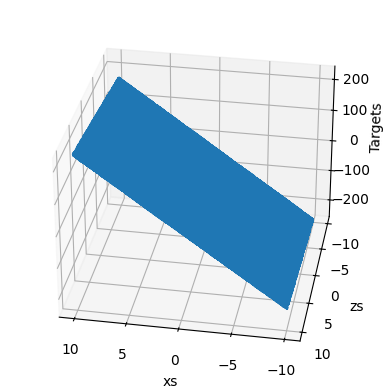

In [4]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [5]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[-0.05584544]
 [-0.05491721]] [0.05017071]


In [6]:
targets = targets.reshape(observations,1)
eta = 0.001
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = targets - outputs

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights + eta * np.dot(inputs.T, deltas_scaled)
  biases = biases + eta * np.sum(deltas_scaled)

7516.721457868781
7028.9212078340815
6572.876544299456
6146.519974553859
5747.918614645524
5375.265425289917
5026.871018394846
4701.155997050257
4396.64379424934
4111.953977868988
3845.7959915519227
3596.963303109357
3364.32793391097
3146.8353444565623
2943.4996529387195
2753.399165115944
2575.6721952271523
2409.5131589982157
2254.168921024996
2108.935379970774
1973.1542760943178
1846.2102066329433
1727.5278355074724
1616.5692846970653
1512.8316954557047
1415.8449483122208
1325.1695315157124
1240.3945482613642
1161.135853660895
1087.0343130102126
1017.7541734568284
952.9815416838004
892.4229607076675
835.8040793372633
782.8684082604527
733.376157118621
687.1031472959787
643.8397954940526
603.390163482704
565.5710697190573
530.2112588062747
497.1506250263536
466.2394864263158
437.33790616638703
410.3150580530475
385.04863338019504
361.4242863889523
339.33511583175965
318.68118029010236
299.3690450482597
281.3113584685539
264.4264559473366
248.6379896560114
233.87458238829984
220.0695039

In [7]:
print(weights, biases)

[[20.27375264]
 [ 2.88732274]] [-0.62065419]


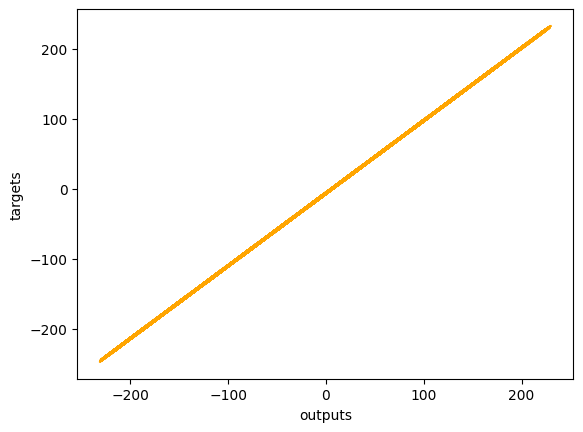

In [8]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()